In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("himanshunakrani/naive-bayes-classification-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'naive-bayes-classification-data' dataset.
Path to dataset files: /kaggle/input/naive-bayes-classification-data


In [ ]:
df = pd.read_csv("/kaggle/input/naive-bayes-classification-data/Naive-Bayes-Classification-Data.csv")

In [ ]:
print("\nFirst 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nStatistical Summary:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())


First 5 rows:
    glucose  bloodpressure  diabetes
0       40             85         0
1       40             92         0
2       45             63         1
3       45             80         0
4       40             73         1

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   glucose        995 non-null    int64
 1   bloodpressure  995 non-null    int64
 2   diabetes       995 non-null    int64
dtypes: int64(3)
memory usage: 23.4 KB
None

Statistical Summary:
           glucose  bloodpressure    diabetes
count  995.000000     995.000000  995.000000
mean    44.306533      79.184925    0.500503
std      6.707567       9.340204    0.500251
min     20.000000      50.000000    0.000000
25%     40.000000      72.000000    0.000000
50%     45.000000      80.000000    1.000000
75%     50.000000      87.000000    1.000000
max     70.

In [ ]:
X = df[['glucose', 'bloodpressure']]
y = df['diabetes']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:
y_pred = nb.predict(X_test_scaled)


Naive Bayes Accuracy: 0.9331103678929766



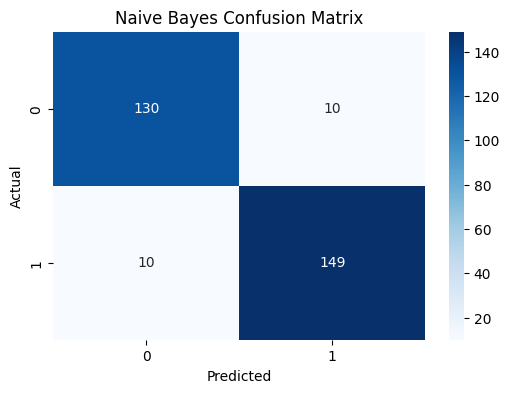


Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       140
           1       0.94      0.94      0.94       159

    accuracy                           0.93       299
   macro avg       0.93      0.93      0.93       299
weighted avg       0.93      0.93      0.93       299



In [ ]:
acc = accuracy_score(y_test, y_pred)
print("\nNaive Bayes Accuracy:", acc)
print("")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))